# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
A model is linear when it is linear in its parameters (coefficients), meaning the parameters appear only as a weighted sum of input features.
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
The intercept represents the baseline category (when the dummy variable = 0). The coefficient of the dummy variable shows how much the predicted value differs from that baseline group.
3. Can linear regression be used for classification? Explain why, or why not.
Yes, linear regression can be used for classification by predicting numeric values and assigning classes using a threshold. However, it is usually not ideal because predictions can fall outside the [0,1] probability range and it does not model probabilities as well as logistic regression.
4. What are signs that your linear model is over-fitting?\
Signs of overfitting include very low training error but high test/validation error, meaning the model performs well on training data but poorly on new data. Another sign is large fluctuations in predictions due to small changes in the data.
5. Clearly explain multi-colinearity using the two-stage least squares technique.
Multicollinearity occurs when one predictor variable can be explained by other predictors. In a two-stage least squares approach, you first regress the problematic variable on the other predictors, then use the predicted values in the main regression to reduce the correlation between variables.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
You can incorporate nonlinear relationships by transforming the features, such as adding polynomial terms or applying functions like log or square root. The model stays linear in the coefficients but captures nonlinear patterns in the data.
7. What is the interpretation of the slope coefficient in a linear regression?
The slope coefficient represents the average change in the dependent variable y for a one-unit increase in the independent variable x, holding all other variables constant.
8. Compare the train/test split and $k$-fold cross validation.
Train/test split divides the data once into a training set and a testing set. k-fold cross-validation repeatedly splits the data into k parts, training on
k−1 folds and testing on the remaining fold, then averages the results for a more reliable estimate of model performance.
9.  How is the $k$ in $k$-fold cross validation typically selected?
The value of k is typically chosen based on common practice and computational cost, with 5 or 10 folds being the most common choices because they balance bias and variance in the performance estimate.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


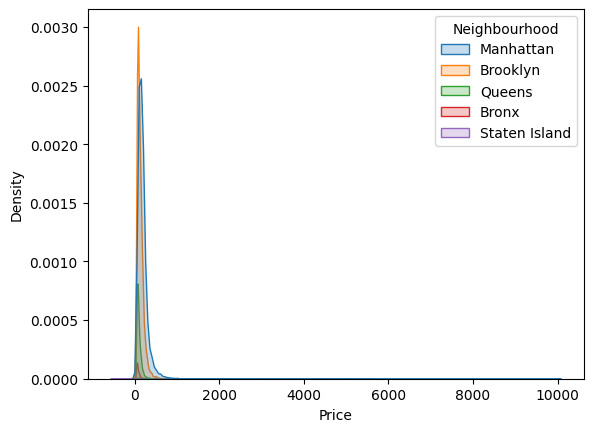

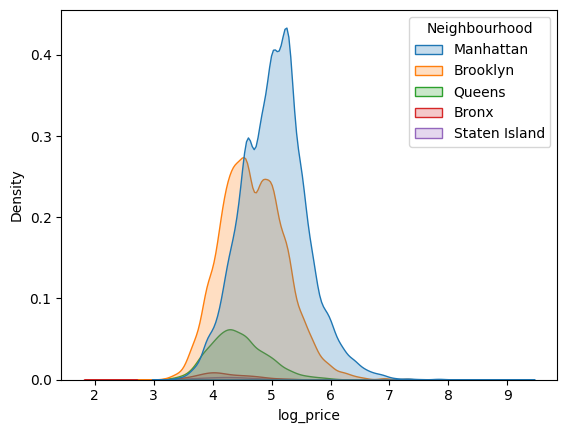

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/junhyoung/ml_container/data/Q1_clean.csv")
df = df.rename(columns={'Neighbourhood ':'Neighbourhood'})

avg = df.groupby('Neighbourhood')[['Price','Review Scores Rating']].mean()
print(avg)
df["log_price"] = np.log(df["Price"])

# KDE price
sns.kdeplot(data=df, x="Price", hue="Neighbourhood", fill=True)
plt.show()

# KDE log price
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood", fill=True)
plt.show()

In [57]:
import statsmodels.api as sm

X = pd.get_dummies(df["Neighbourhood"], drop_first=True)
X = X.astype(int)
X = sm.add_constant(X)
y = df["Price"].astype(float)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        21:44:55   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

If we drop the first category, the intercept represents the average price of the baseline borough (the dropped one). Each coefficient shows the difference in average price between that borough and the baseline borough.Therefore, the conditional group means from part 1 equal the intercept plus the corresponding dummy coefficient. For the baseline borough, the mean price equals the intercept itself.

In [58]:
X = sm.add_constant(df["Review Scores Rating"])
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        21:44:55   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

The slope coefficient shows the average change in price for a one-point increase in the review score. For example, if the slope were 2, it would mean each additional rating point is associated with about $2 higher price per night on average.

In [59]:
X = pd.get_dummies(df["Neighbourhood"], drop_first=True).astype(int)

X["Review Scores Rating"] = df["Review Scores Rating"]
X = sm.add_constant(X)
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        21:44:55   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

After adding Neighbourhood, the slope on Review Scores Rating typically becomes smaller because part of the price differences were actually due to location. The neighborhood averages now represent price differences between boroughs while holding the review score constant, so they may shift slightly compared to the simple averages from part 1.

In [60]:
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True).astype(int)

for col in dummies.columns:
    df[f"score_{col}"] = df["Review Scores Rating"] * dummies[col]

X = pd.concat([dummies, df[[f"score_{c}" for c in dummies.columns]]], axis=1)
X = sm.add_constant(X)

y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     200.7
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:44:55   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22144   BIC:                         2.831e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  75.2765    

The slopes show how the effect of review scores on price differs by neighborhood. If the coefficients are close to each other, the relationship between rating and price is similar across boroughs; if they differ a lot, it means ratings affect prices differently depending on the neighborhood.

In [61]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

y = df["Price"]

# Model 4: Neighbourhood + Review Score
X4 = pd.get_dummies(df["Neighbourhood"], drop_first=True)
X4["Review Scores Rating"] = df["Review Scores Rating"]

# Model 5: Interaction (separate slope by neighbourhood)
X5 = pd.get_dummies(df["Neighbourhood"], drop_first=True)
for col in X5.columns:
    X5[f"score_{col}"] = df["Review Scores Rating"] * X5[col]
X5["Review Scores Rating"] = df["Review Scores Rating"]

# Cross-validation (5-fold)
model = LinearRegression()

cv4 = cross_val_score(model, X4, y, cv=5, scoring="neg_mean_squared_error")
cv5 = cross_val_score(model, X5, y, cv=5, scoring="neg_mean_squared_error")

print("Model 4 CV MSE:", -cv4.mean())
print("Model 5 CV MSE:", -cv5.mean())

Model 4 CV MSE: 21113.112422262086
Model 5 CV MSE: 21418.246870450363


Cross-validation splits the data into several folds, trains the model on part of the data, and tests it on the remaining part. The model with the lower average test MSE performs better out-of-sample. So, Model 4.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


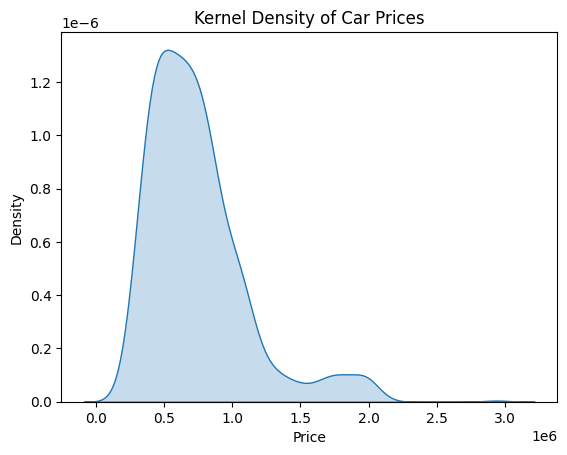

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


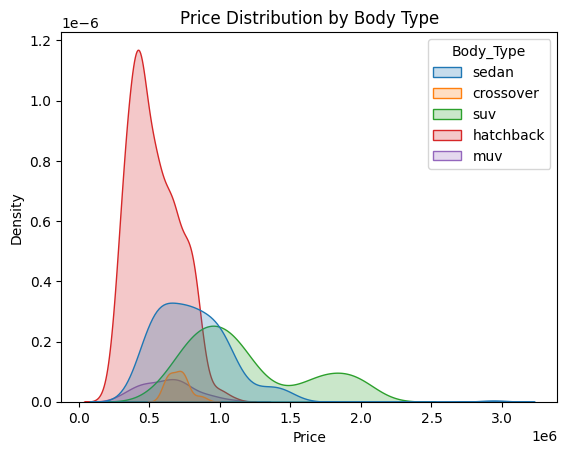

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cars = pd.read_csv("/Users/junhyoung/ml_container/data/cars_hw.csv")

print(cars["Price"].describe())

sns.kdeplot(data=cars, x="Price", fill=True)
plt.title("Kernel Density of Car Prices")
plt.show()

summary = cars.groupby("Body_Type")["Price"].describe()
print(summary)

sns.kdeplot(data=cars, x="Price", hue="Body_Type", fill=True)
plt.title("Price Distribution by Body Type")
plt.show()

In [63]:
from sklearn.linear_model import LinearRegression

X = cars[["Seating_Capacity"]]
y = cars["Price"]

model = LinearRegression().fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

X_cat = pd.get_dummies(cars["Seating_Capacity"], drop_first=True)

model_cat = LinearRegression().fit(X_cat, y)

print(dict(zip(X_cat.columns, model_cat.coef_)))

Slope: 59267.9980367217
Intercept: 439032.0141018268
{5: np.float64(546483.8709677402), 6: np.float64(1455999.9999999998), 7: np.float64(735948.7179487178), 8: np.float64(271800.0000000001)}


The slope is 59,268, meaning that each additional seat is associated with about 59,268 rupees higher car price on average. The intercept (439,032) represents the predicted price when seating capacity is zero, though this value is not practically meaningful. Moreover, the coefficients represent the price difference relative to the baseline seating capacity (the dropped category, likely 4 seats). The differences are not increasing smoothly (e.g., 6 seats ≈ 1,456,000 while 7 seats ≈ 735,949), so the relationship between price and seating capacity is not roughly linear.

In [64]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

cars["Age"] = cars["Make_Year"].max() - cars["Make_Year"]

y = cars["Price"]

results = {}

for d in range(1,7):
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    score = cross_val_score(model, cars[["Age"]], y, cv=10,
                            scoring="neg_mean_squared_error").mean()
    results[d] = -score

print(results)

{1: np.float64(100295370079.45541), 2: np.float64(100814620596.42151), 3: np.float64(100380163091.91905), 4: np.float64(100474431121.11778), 5: np.float64(100131346195.53839), 6: np.float64(100347765583.31784)}


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


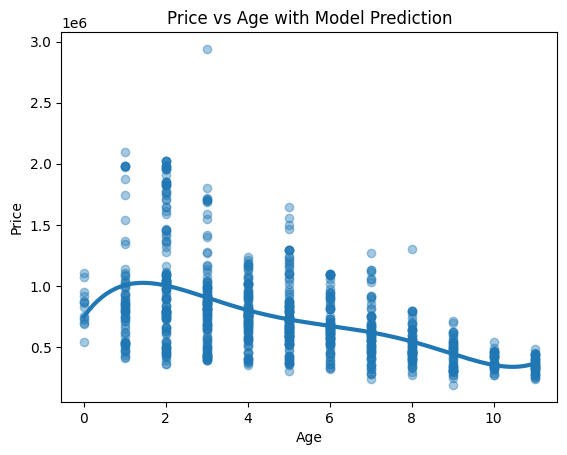

In [65]:
import matplotlib.pyplot as plt

best_degree = min(results, key=results.get)

model = make_pipeline(PolynomialFeatures(best_degree), LinearRegression())
model.fit(cars[["Age"]], y)

age_grid = np.linspace(cars["Age"].min(), cars["Age"].max(), 200).reshape(-1,1)
pred = model.predict(age_grid)

plt.scatter(cars["Age"], cars["Price"], alpha=0.4)
plt.plot(age_grid, pred, linewidth=3)
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Model Prediction")
plt.show()

The prediction line follows the downward trend of prices as cars get older so the model fits the data well.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [66]:
import pandas as pd

heart = pd.read_csv("/Users/junhyoung/ml_container/data/heart_hw.csv")

survival_rates = heart.groupby("transplant")["y"].mean()
print(survival_rates)

ATE = survival_rates["treatment"] - survival_rates["control"]
print("ATE:", ATE)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
ATE: 0.23017902813299232


In [67]:
import statsmodels.api as sm

heart["treatment"] = (heart["transplant"] == "treatment").astype(int)

X = sm.add_constant(heart["treatment"])
y = heart["y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Mon, 16 Mar 2026   Prob (F-statistic):             0.0133
Time:                        21:44:55   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1176      0.075      1.574      0.1

In [68]:
import matplotlib.pyplot as plt

heart["treatment"] = (heart["transplant"]=="treatment").astype(int)

X = sm.add_constant(heart[["treatment","age"]])
y = heart["y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           0.000357
Time:                        21:44:55   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7020      0.196      3.583      0.0

If the ATE from part 1 is larger than 0.2647, then the ATE overestimates the transplant benefit for all ages. If the ATE is smaller, then the ATE underestimates the benefit.

In [69]:
heart["treatment"] = (heart["transplant"]=="treatment").astype(int)

heart["treat_age"] = heart["treatment"] * heart["age"]

X = sm.add_constant(heart[["treatment","age","treat_age"]])
y = heart["y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           0.000310
Time:                        21:44:55   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3549      0.280      1.269      0.2

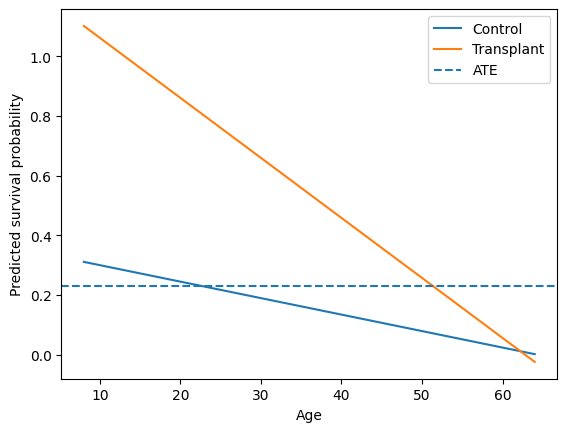

In [70]:
ages = np.linspace(heart["age"].min(), heart["age"].max(),100)

pred_control = model.params["const"] + model.params["age"]*ages
pred_treat = (model.params["const"] 
              + model.params["treatment"] 
              + (model.params["age"] + model.params["treat_age"])*ages)

ATE = heart.groupby("transplant")["y"].mean()["treatment"] - \
      heart.groupby("transplant")["y"].mean()["control"]

plt.plot(ages,pred_control,label="Control")
plt.plot(ages,pred_treat,label="Transplant")
plt.axhline(ATE,linestyle="--",label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.legend()
plt.show()

Transplants help younger patients much more and the benefit declines as patients get older.

In [71]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

heart["treatment"] = (heart["transplant"]=="treatment").astype(int)
heart["treat_age"] = heart["treatment"] * heart["age"]

y = heart["y"]

# Model 1: transplant only
X1 = heart[["treatment"]]

# Model 2: transplant + age
X2 = heart[["treatment","age"]]

# Model 3: transplant + age + interaction
X3 = heart[["treatment","age","treat_age"]]

model = LinearRegression()

cv1 = -cross_val_score(model, X1, y, cv=10, scoring="neg_mean_squared_error").mean()
cv2 = -cross_val_score(model, X2, y, cv=10, scoring="neg_mean_squared_error").mean()
cv3 = -cross_val_score(model, X3, y, cv=10, scoring="neg_mean_squared_error").mean()

print("Model 1 MSE:", cv1)
print("Model 2 MSE:", cv2)
print("Model 3 MSE:", cv3)

Model 1 MSE: 0.20970277289824915
Model 2 MSE: 0.19922806049232314
Model 3 MSE: 0.19609811380122735


A key concern is that the model is very simple and only uses age and transplant status, while real transplant decisions depend on many other medical factors like overall health and disease severity. Because the data are observational, the estimated treatment effects may also be biased if transplant patients differ systematically from control patients. In addition, using the model for allocation could raise ethical issues, such as unfairly prioritizing younger patients if survival probabilities decline with age.